In [1]:
#%config InlineBackend.figure_formats=['svg']

from os import listdir
import numpy as np
import matplotlib.pyplot as plt

from ExistingAlgorithms.Plot import plot_1D, plot_traces

from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.compare import compare
from AutoencoderAPI.utils.clustering.kernelDensity import kernel_density
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from AutoencoderAPI.utils.clustering.GaussianMixture import gaussian_mixture
from AutoencoderAPI.utils.clustering.GaussianMixture2D import gaussian_mixture_2d
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.PIKA import PIKA
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.cluster import KMeans
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding
from sklearn.manifold import trustworthiness

In [2]:
Average = [7.08211260e+06, 5.15056588e+06, 3.72436481e+06, 2.71572185e+06,
                1.97472603e+06, 1.42408918e+06, 1.02232317e+06, 7.32125310e+05,
                5.24090642e+05, 3.74998464e+05, 2.66916821e+05, 1.89078950e+05,
                1.35700261e+05, 9.74077327e+04, 6.94691976e+04, 4.90518881e+04,
                3.50311232e+04, 2.50723929e+04, 1.77261578e+04, 1.26385561e+04,
                9.03448510e+03, 6.34776305e+03, 4.44228612e+03, 3.11561879e+03,
                2.20105919e+03, 1.55472974e+03, 1.10119877e+03, 7.74547737e+02,
                5.46214434e+02, 3.86814856e+02, 2.77270797e+02, 1.97954232e+02,
                1.39667657e+02, 9.96796628e+01, 7.12159618e+01, 5.03875460e+01,
                3.56871128e+01, 2.54771649e+01, 1.80622346e+01, 1.27380046e+01,
                9.02367143e+00, 6.40704597e+00, 4.54269070e+00, 3.20272751e+00,
                2.26309906e+00]
dB = [10.,  10.5, 11.,  11.5, 12.,  12.5, 13.,  13.5,
        14.,  14.5, 15.,  15.5, 16.,  16.5, 17.,  17.5, 18.,  18.5, 19.,  19.5, 20.,  20.5,
        21.,  21.5, 22.,  22.5, 23.,  23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5,
        28.,  28.5, 29. ]
dB = [str(i) for i in dB]
# 20 
#weights = [0.0003192005558069908, 0.00031920054140233156, 0.0003192047717196186, 0.00031896993386863303, 0.00032428734151548883, 0.00026028418971960613, 3.334106202098874e-11, 2.1820951996022104e-15, 0.6859566123464593, 0.9999999999999989, 0.14356940915685718, 0.6479502468083013, 4.329172873624568e-15, 8.821627242543525e-20, 0.5835324238574539]
# 80
#weights = [0.00039148050828823516, 0.00039147234552934106, 0.00039387216928515325, 6.77292452968209e-18, 0.8153704319746325, 0.6732399719408253, 0.4527560469839631, 0.3229106530151291, 0.23700976744898386, 0.16810435612198651, 0.09820452099430489, 0.1352441273802062, 1.359774208831408e-21, 1.316395858369459e-22, 0.14910362219668563]
# 60
#weights = [0.6482595150027572, 0.32720086435047546, 0.2770783073688964, 0.1759495583327923, 0.1461905755358196, 0.06955888385950298, 0.11219825231349285, 2.3103182583666624e-09, 6.140950720190689e-07, 0.11878269583499049]
# 25
#weights = [0.0003476770445062025, 0.00034767696667116916, 0.000347699823077582, 0.00034643098200887006, 0.0003752801530447702, 2.801199297331306e-07, 5.32327556555495e-18, 0.2884298482510668, 0.9999999999999999, 0.44831933497653087, 0.3446223867963122, 0.4274545294834902, 4.435483229458253e-23, 6.217569402094733e-28, 0.47704268666320976]
# 30 
#weights = [0.00011103968004035224, 0.00011089801243560565, 0.00011069554964499119, 0.00011024960238901754, 0.00011310336185720763, 2.3286029946268364e-14, 6.895773677703348e-29, 0.9939426192437916, 0.608654865892155, 0.45013829394986765, 0.26566105348285857, 0.35792439346736743, 1.710677207550967e-30, 4.133333755751823e-17, 0.3980443177061107]
# 40 
weights = [0.0005418242295701225, 0.0005355464852328582, 0.0005288419693377203, 0.0005451083117065165, 5.817103308395239e-05, 5.458653579755925e-26, 0.8227111499610864, 0.7137555134020424, 0.42114060328674213, 0.3823884641101795, 0.16064055881793324, 0.28643980728555124, 8.603089025900766e-22, 5.730503440553129e-29, 0.296211348430319]
# 100 weights = np.array([6.4068191966538536e-18, 0.600386681374612, 0.4830115039147191, 0.35087519998498806, 0.24408420219919305, 0.170818308102021, 0.12742618799637714, 0.08877921602628788, 0.05305222246494956, 0.07182633946492017, 2.4515645251645102e-06, 1.3809092142528948e-06, 0.07955774083086532]) 
# geometric
#weights = [0.0003100487694493039, 0.0003100525908544996, 0.0003089303424391619, 0.00037203226497811937, 0.002119604522230985, 0.010749437226769723, 0.0364470541807536, 0.06078284674938013, 0.11941098007226632, 0.09471524872401249, 0.14862215617099891, 0.1608256232165096, 4.247596938620747e-31, 1.4221872390832414e-28, 0.3278863549470811]
#weights = [0.99]*8 + [0.99]
#weights = [1]
weights = np.array([0]*(len(dB) - len(weights)) + weights)
weights = weights/np.max(weights)
weights

#print("Weights Average")
#for w, a in zip(weights, Average):
#        print(w," ",a)

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       6.58583793e-04, 6.50953236e-04, 6.42803941e-04, 6.62575573e-04,
       7.07065087e-05, 6.63495758e-26, 1.00000000e+00, 8.67565139e-01,
       5.11893638e-01, 4.64790667e-01, 1.95257544e-01, 3.48165705e-01,
       1.04569982e-21, 6.96538930e-29, 3.60042949e-01])

In [3]:
signal_size = 8192
certain_clusters = 23
interval = [0,270]
path_test = r'Datasets/TES/NIST test/'
path_train = r'Datasets/TES/NIST train/'
files_test = listdir(path_test)
files_train = listdir(path_train)
file_weight_test = [int(weights[dB.index(i[67:71])] * 1_024) for i in files_test]
file_weight_train = [int(weights[dB.index(i[67:71])] * 1_024) for i in files_train]
path_model = 'grid-search-TES 2D 3/run 34/fold 0'#'grid-search-TES 2D 1/run 34/fold 0'#'run-2024-02-22-18-45/fold 0'#'grid-search-TES Triplet 19/run 01/fold 0'#'grid-search-TES Triplet 19/run 19/fold 0'#'run-2024-01-18-18-15/fold 0'
path_save = r'MetricLog/Metric_TES_2D_40photons'
mean, std = 1,1#load_mean_std(path_model)
print(mean, std)

X_test = -1*np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size)[:w,interval[0]:interval[1]] for w, fileName in zip(file_weight_test, files_test)]).astype("float")
X_train = -1*np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size)[:w,interval[0]:interval[1]] for w, fileName in zip(file_weight_train, files_train)]).astype("float")

X_test = (X_test - mean)/std
X_train = (X_train - mean)/std

data_train = (np.copy(X_train) -np.min(X_train)) / (np.max(X_train)-np.min(X_train)) 
data_test = (np.copy(X_test) -np.min(X_test)) / (np.max(X_test)-np.min(X_test)) 

1 1


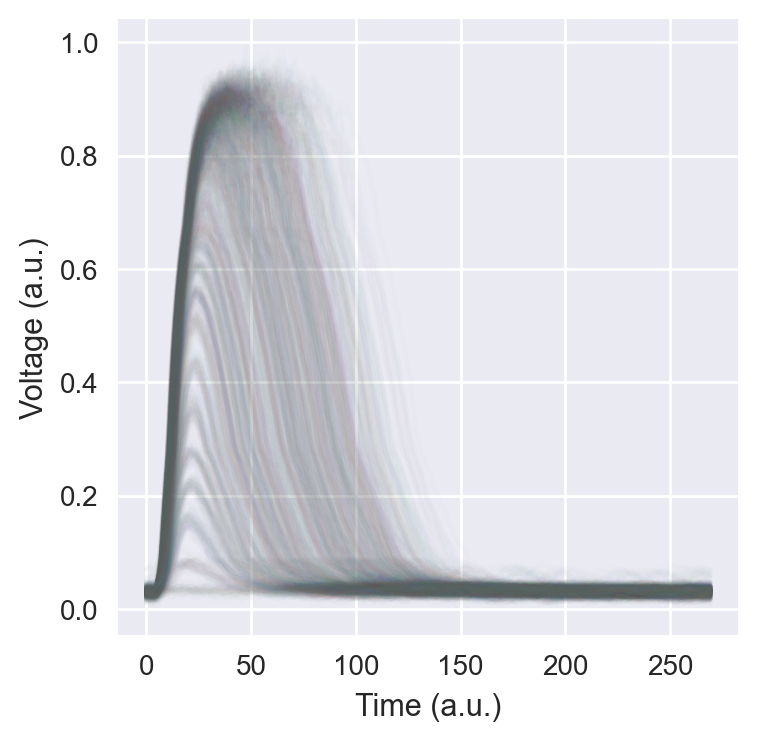

In [5]:
plot_traces(data_test)

### PIKA

In [11]:
pk = PIKA(n_iter = 100, n_epoch = 10, N_mean = [2, 3])
pk.run_PIKA(X_test, plot=True)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

ValueError: operands could not be broadcast together with shapes (2,) (10240,) 

### Max Value

In [4]:
X_i_MAX, X_r_MAX, X_l_MAX = max_value(data_test, filter=True)
#trust_MAX_eucl = trustworthiness(data_test, X_l_MAX, metric="euclidean")
#trust_MAX_cos = trustworthiness(data_test, X_l_MAX, metric="cosine")

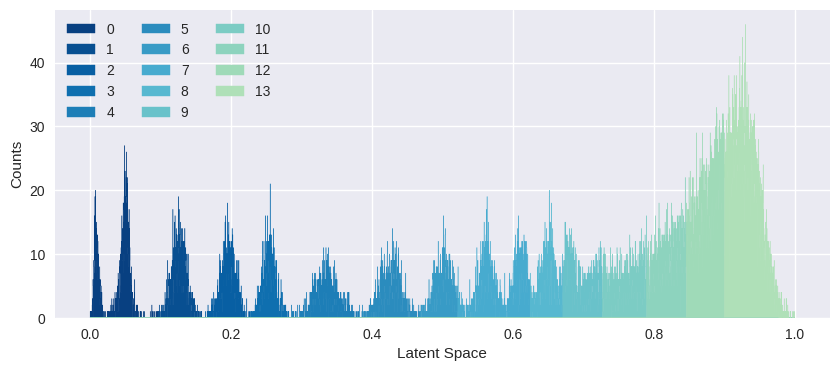

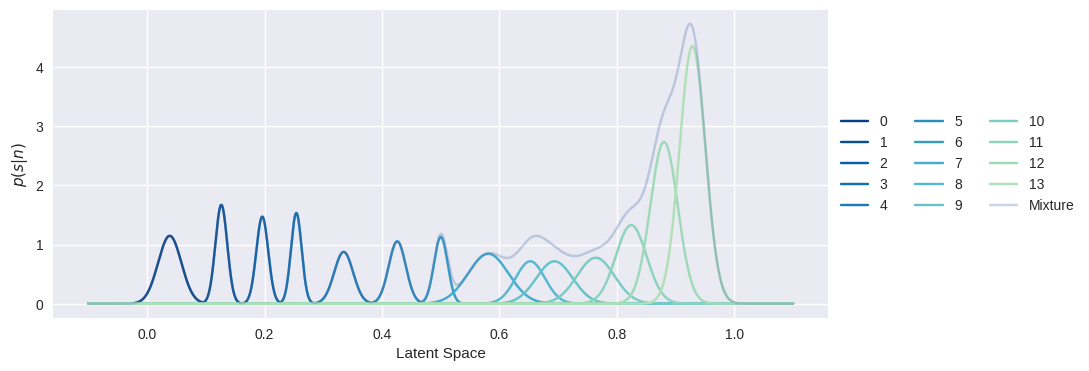

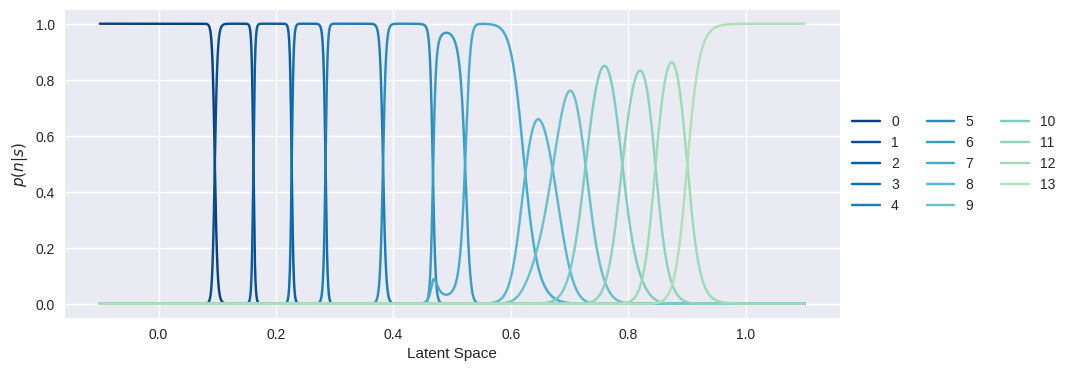

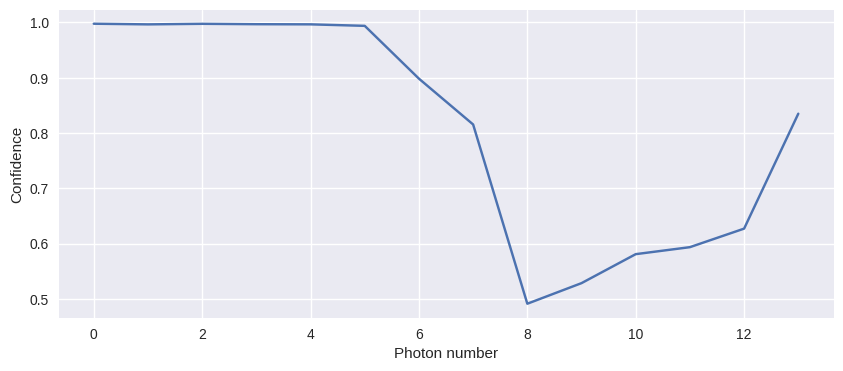

In [5]:
kd = gaussian_mixture(X_l_MAX, 
                    number_cluster=14,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### Area

In [20]:
X_i_AREA, X_r_AREA, X_l_AREA = area(data_test[np.max(data_test,axis=1) > 0.1], filter=True, threshold_cst=0.1)
#trust_AREA_eucl = trustworthiness(data_test, X_l_AREA, metric="euclidean")
#trust_AREA_cos = trustworthiness(data_test, X_l_AREA, metric="cosine")

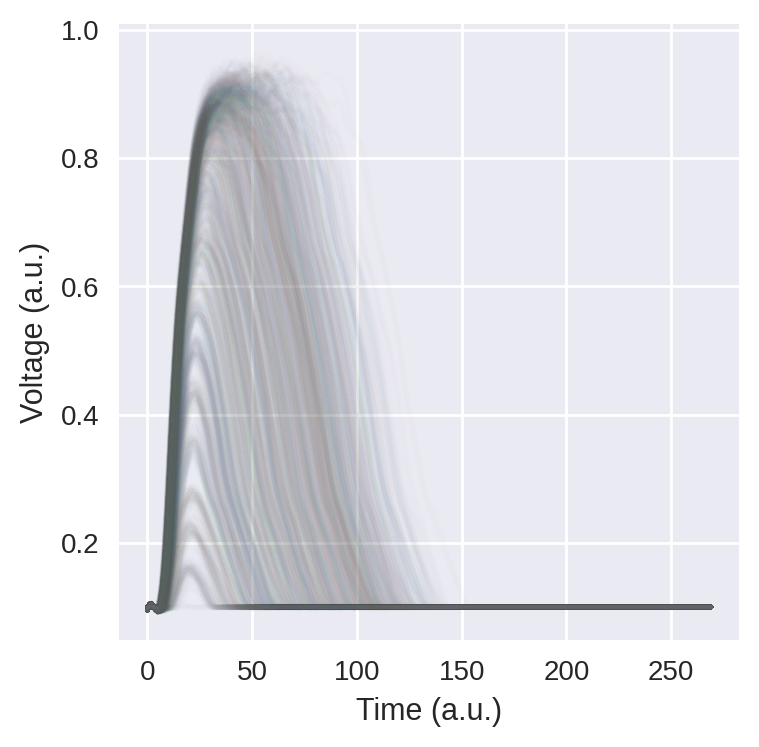

In [15]:
plot_traces(X_i_AREA)

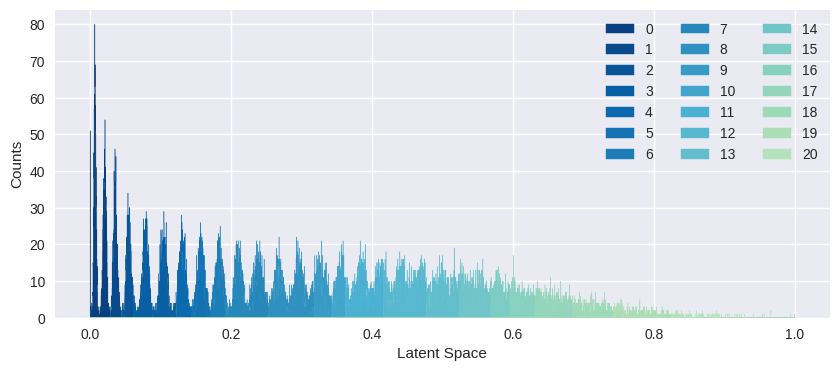

In [23]:
kd = gaussian_mixture(X_l_AREA, 
                    number_cluster=21,
                    flip = False)

kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()

X_l_AREA = kd.normalize_latent(X_l_AREA, certain_clusters)

### Principal Component Analysis (PCA)

In [4]:
X_i_PCA, X_l_PCA = dimension_reduction(data_train,data_test, path_save,PCA,n_components=2) 
#trust_PCA_eucl = trustworthiness(data_test, X_l_PCA, metric="euclidean")
#trust_PCA_cos = trustworthiness(data_test, X_l_PCA, metric="cosine")

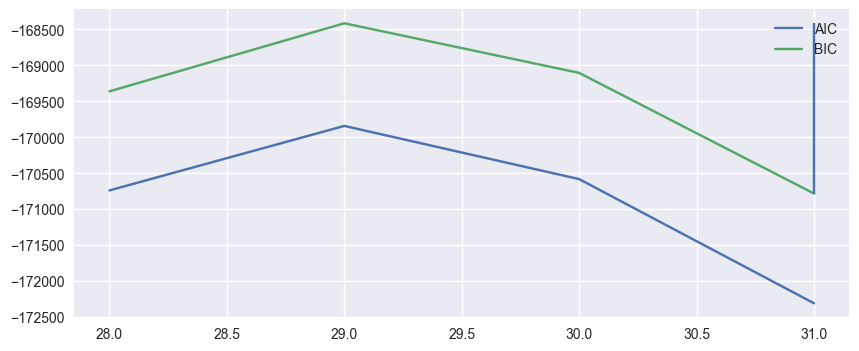

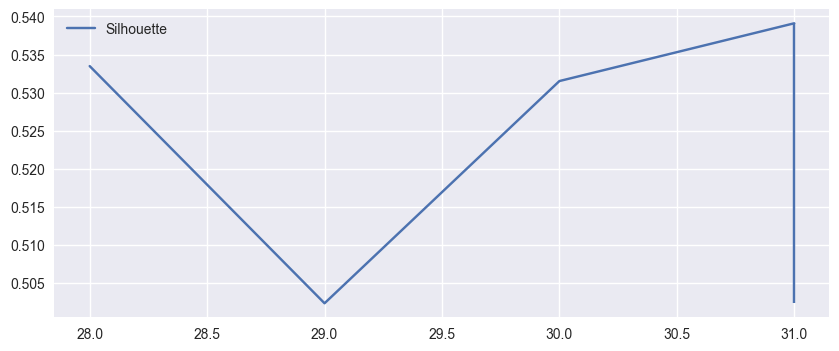

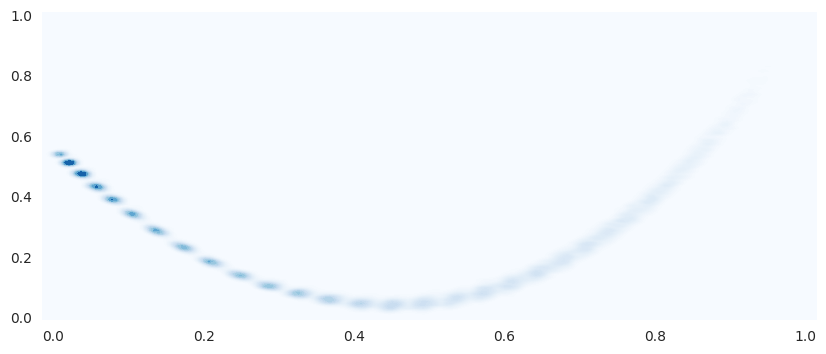

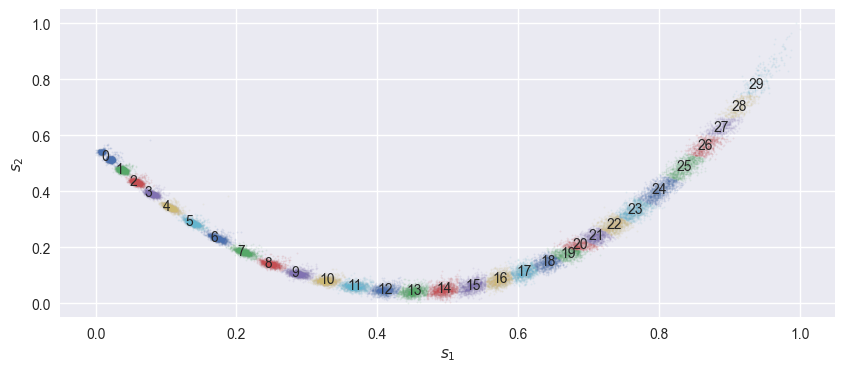

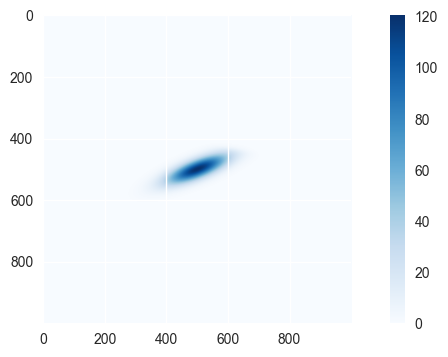

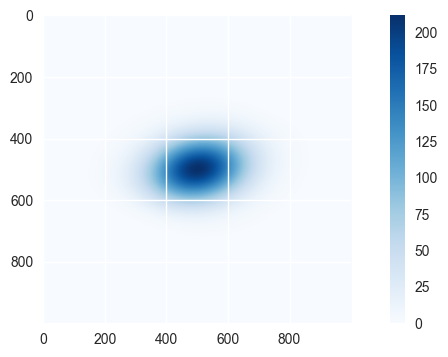

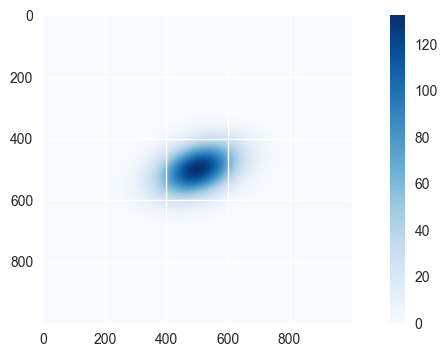

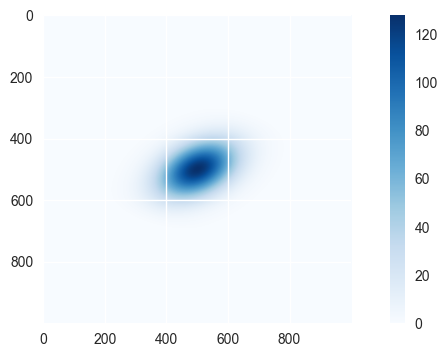

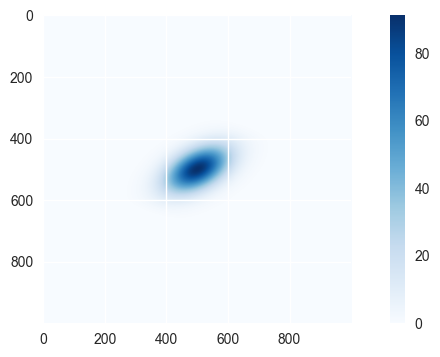

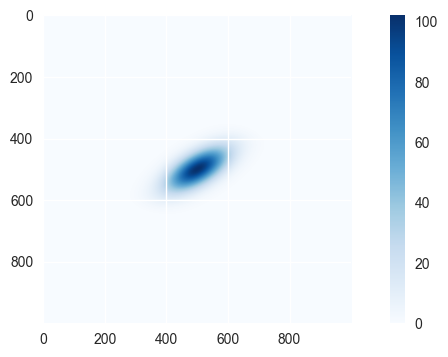

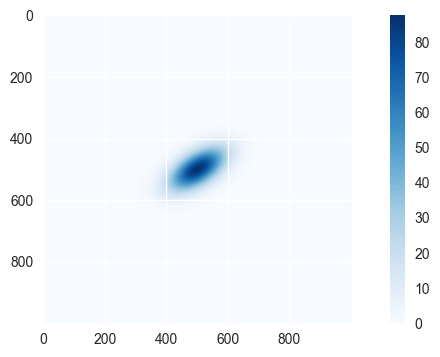

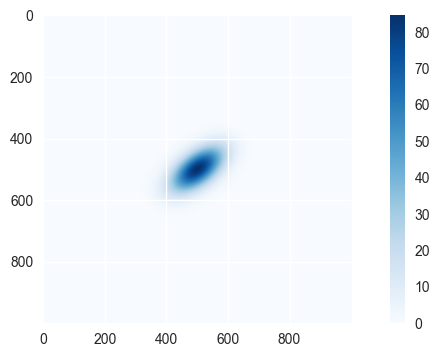

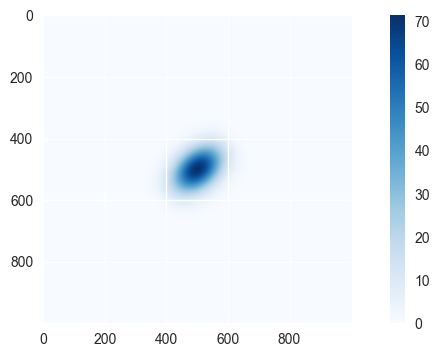

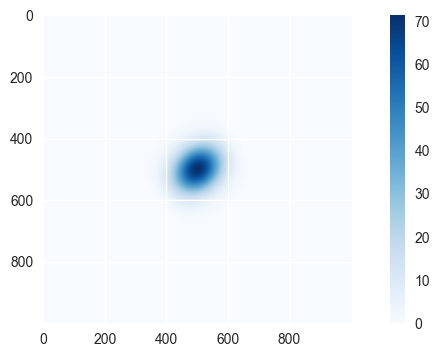

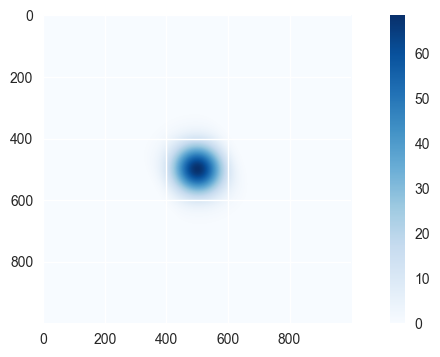

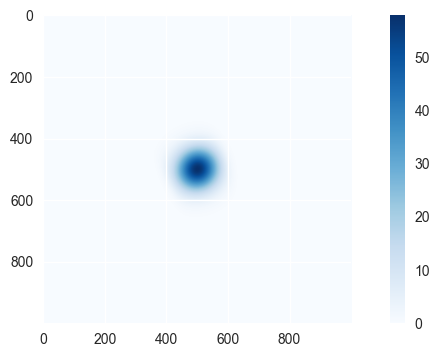

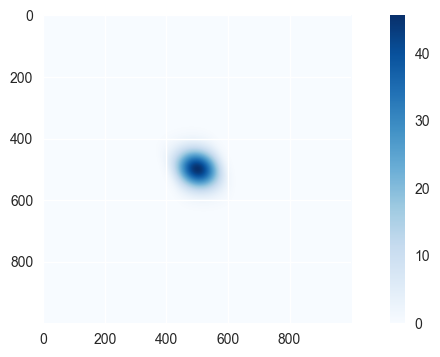

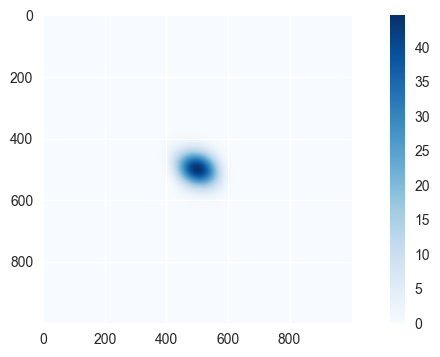

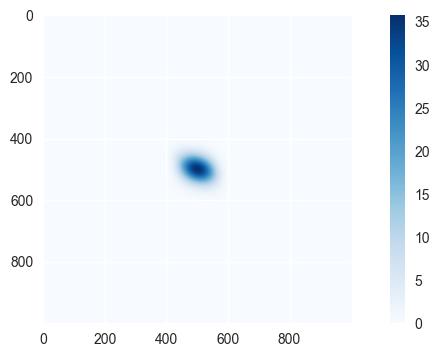

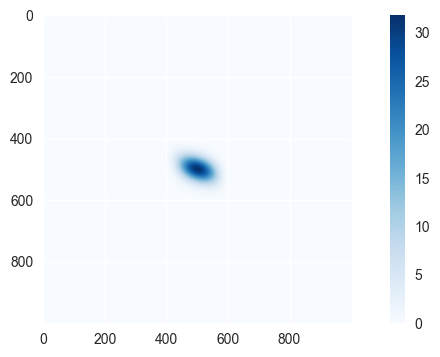

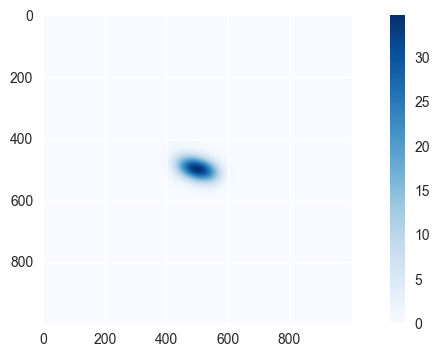

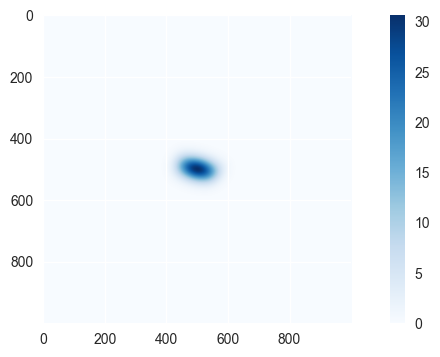

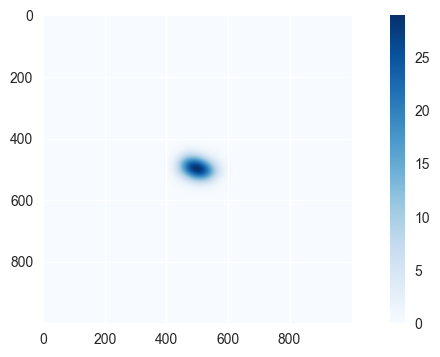

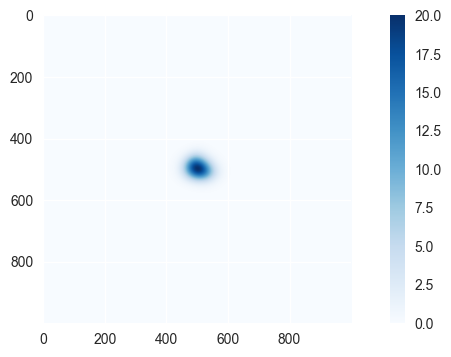

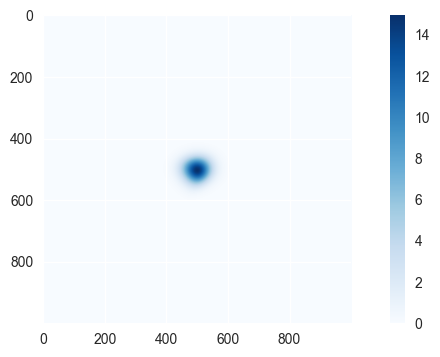

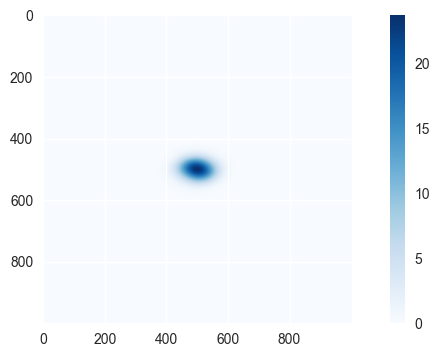

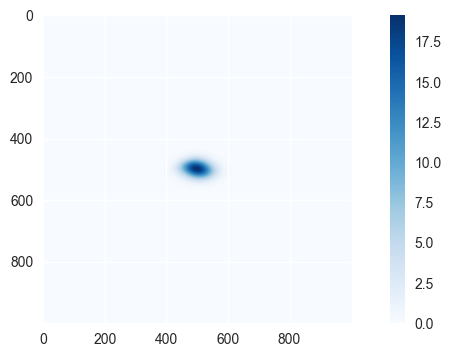

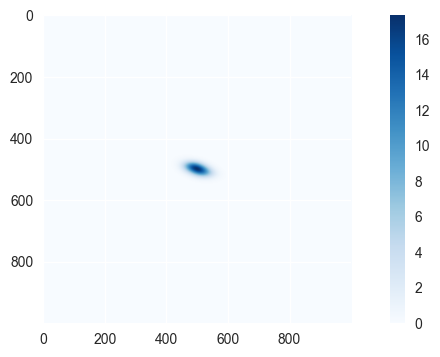

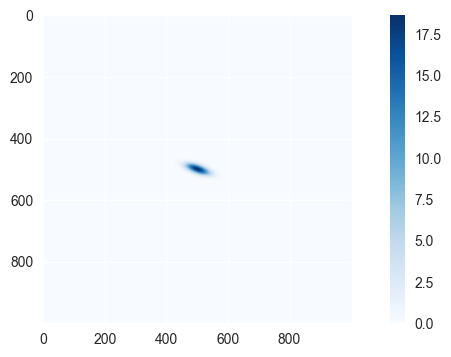

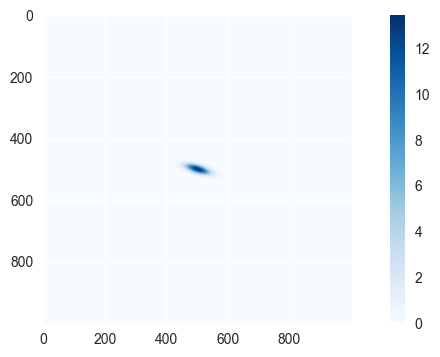

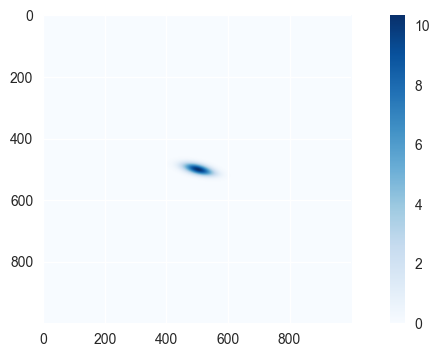

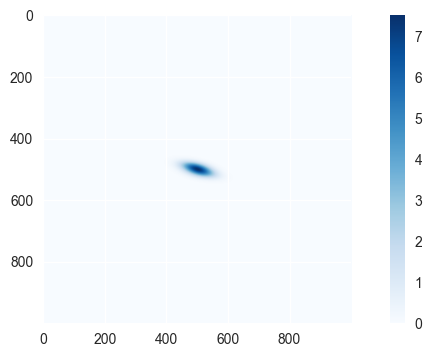

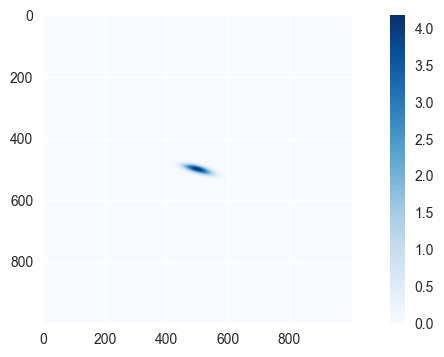

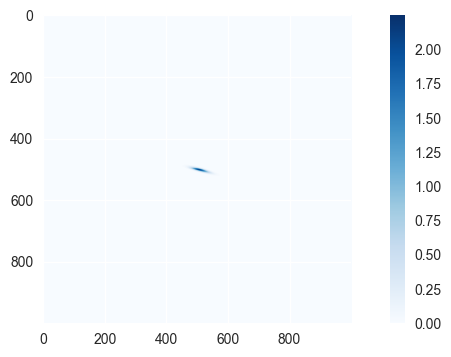

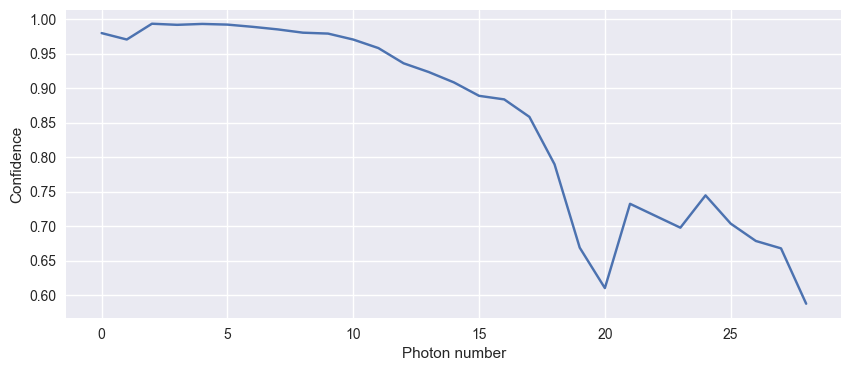

In [5]:
kd = gaussian_mixture_2d(X_l_PCA, data_test,
                    number_cluster = 30,
                    cluster_iter = 2,
                    info_sweep = 2,
                    dx = 1e-3,
                    plot_sweep = True)

kd.plot_density(bw_adjust = 0.1)


kd.plot_cluster()
#kd.plot_psn()
#kd.plot_traces_average()
kd.plot_confidence()
#kd.plot_trustworthiness()
conf_PCA = kd.confidence

### Kernel PCA (Polynomial)

In [ ]:
X_i_KPCA_P, X_l_KPCA_P = dimension_reduction(data_train,data_test, path_save, KernelPCA,n_components=2, kernel="poly", gamma=2, fit_inverse_transform=True)

KeyboardInterrupt: 

In [ ]:
kd = gaussian_mixture_2d(X_l_KPCA_P, data_test,
                    number_cluster=28,
                    dx = 1e-4)#17,

kd.plot_density(bw_adjust=0.15)
kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()

X_l_KPCA_P = kd.normalize_latent(X_l_KPCA_P, certain_clusters)

In [ ]:
kd = gaussian_mixture(X_l_KPCA_P, 
                    number_cluster=23,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### Kernel PCA (Radial basis function)

In [34]:
X_i_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(data_train,data_test, path_save,KernelPCA,n_components=2,kernel="rbf",gamma=2, fit_inverse_transform=True)
#trust_KPCA_RBF_eucl = trustworthiness(data_test, X_l_KPCA_RBF, metric="euclidean")
#trust_KPCA_RBF_cos = trustworthiness(data_test, X_l_KPCA_RBF, metric="cosine")

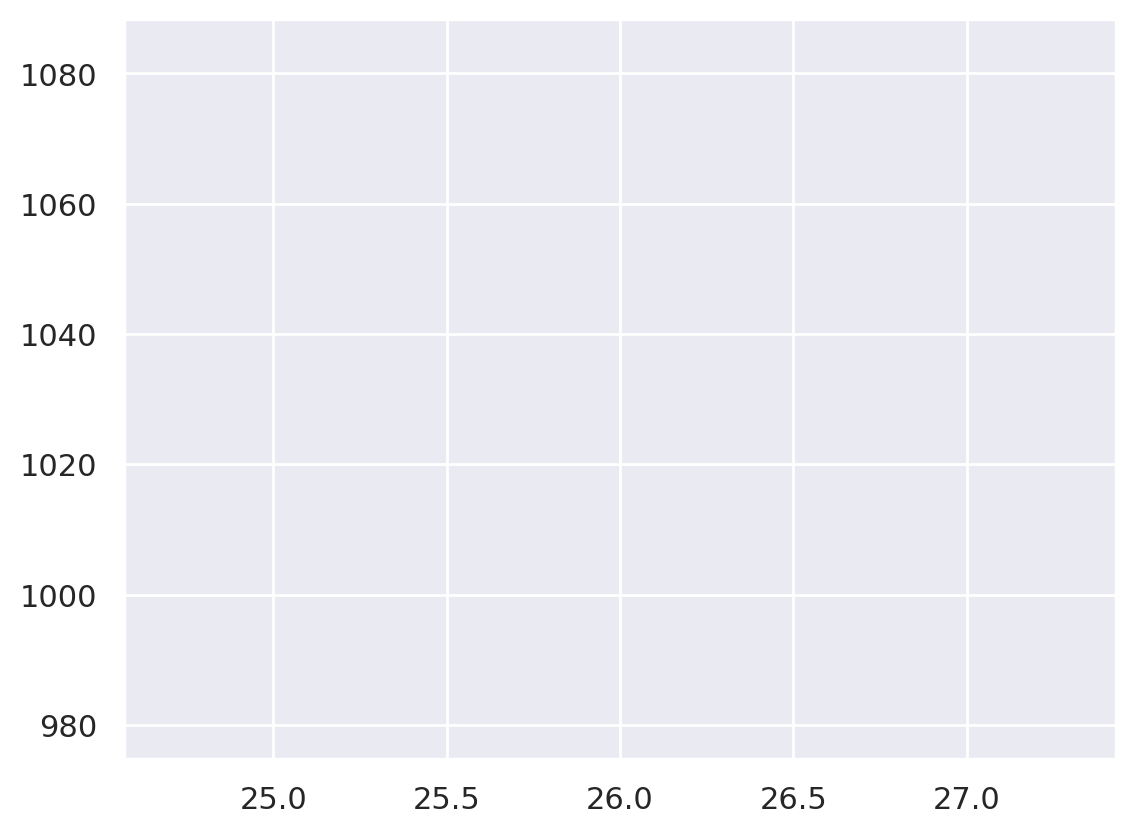

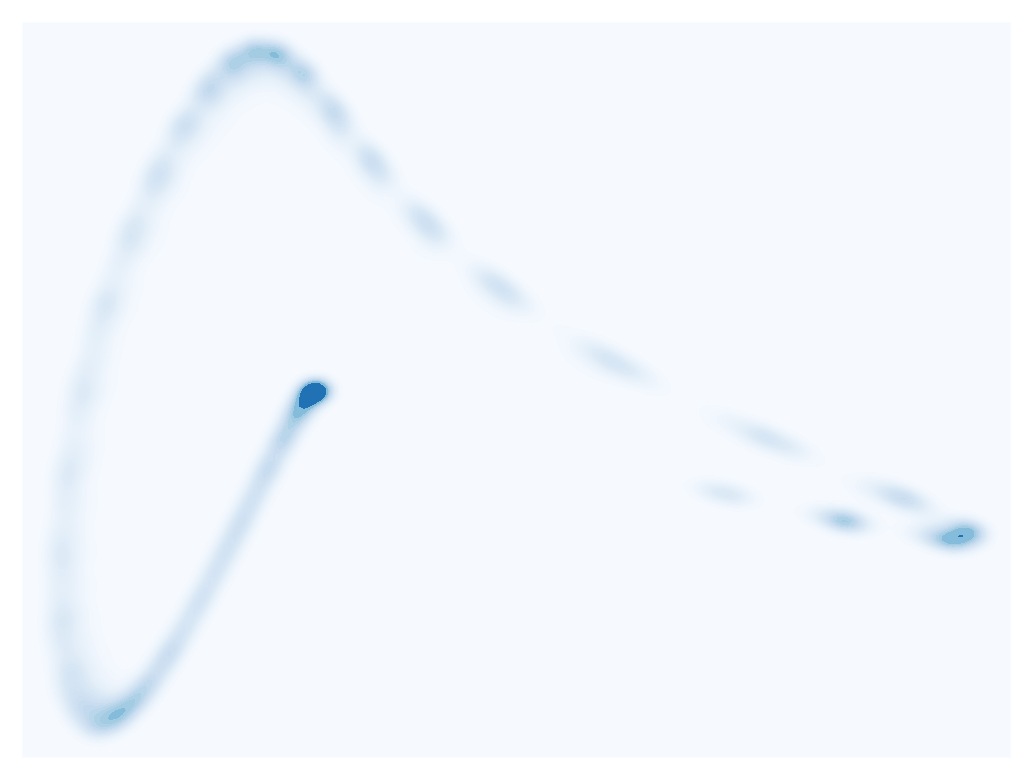

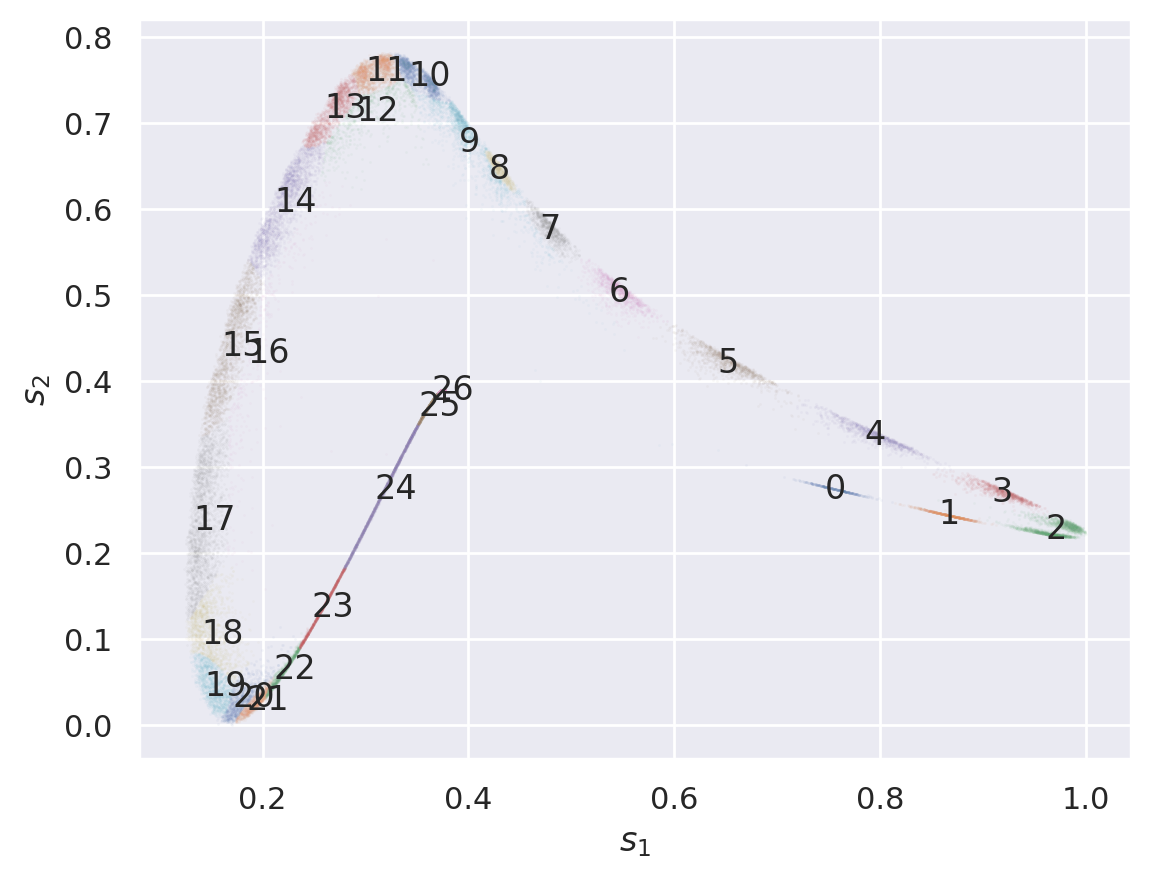

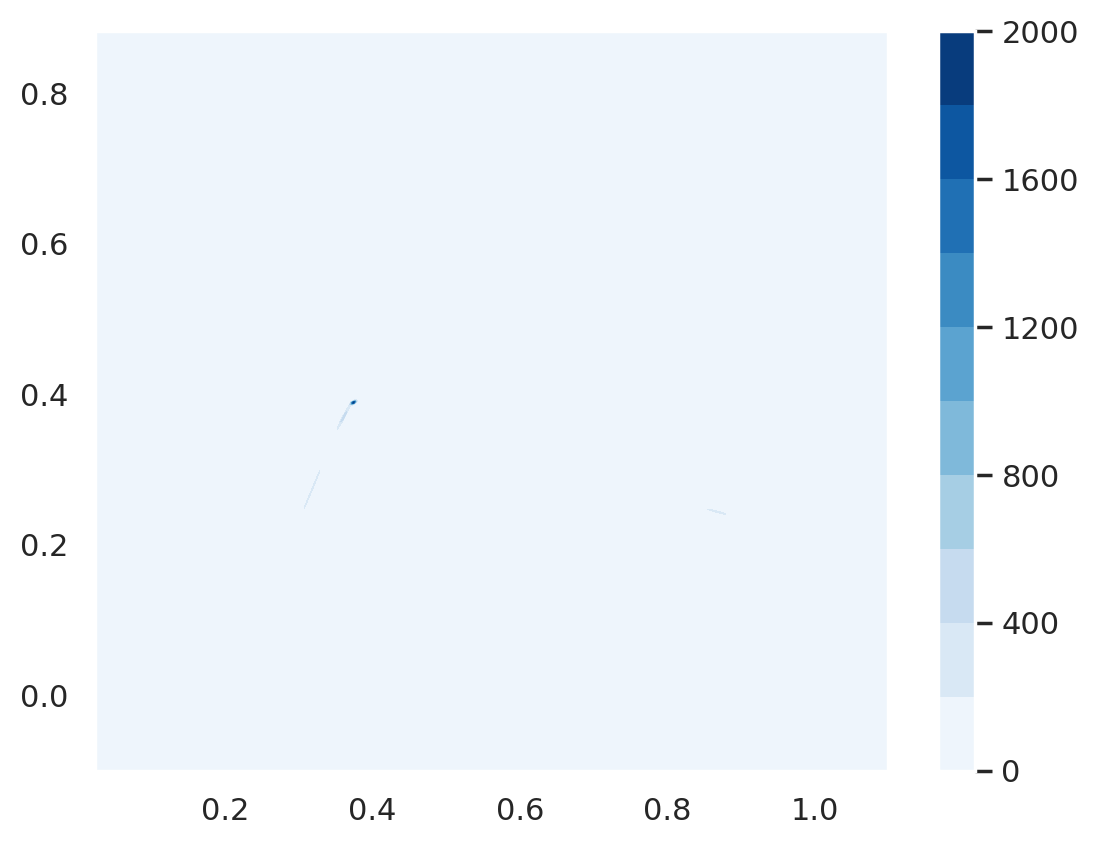

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/GaussianMixture2D.py:260: RuntimeWarning: invalid value encountered in divide
  self.p_ns = self.p_sn / self.p_s#self.p_sn * self.p_n / self.p_s#


In [35]:
kd = gaussian_mixture_2d(X_l_KPCA_RBF, data_test,
                    number_cluster=27,
                    dx = 1e-4)#17,

kd.plot_density(bw_adjust=0.2)
kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
#kd.plot_confidence()

In [ ]:
kd = gaussian_mixture(X_l_KPCA_RBF, 
                    number_cluster=23,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### Kernel PCA (Sigmoid)

In [8]:
X_i_KPCA_S, X_l_KPCA_S = dimension_reduction(data_train,data_test, path_save,KernelPCA,n_components=2,kernel="sigmoid",gamma=0.01, fit_inverse_transform=True)
trust_KPCA_S_eucl = trustworthiness(data_test, X_l_KPCA_S, metric="euclidean")
trust_KPCA_S_cos = trustworthiness(data_test, X_l_KPCA_S, metric="cosine")

In [ ]:
kd = gaussian_mixture_2d(X_l_KPCA_S, data_test,
                    number_cluster=2,
                    dx = 1e-4)#17,

kd.plot_density(bw_adjust=0.1)
#kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()

In [ ]:
kd = gaussian_mixture(X_l_KPCA_S, 
                    number_cluster=23,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### Kernel PCA (Cosine)

In [9]:
X_i_KPCA_C, X_l_KPCA_C = dimension_reduction(data_train,data_test, path_save,KernelPCA,n_components=2,kernel="cosine",gamma=2, fit_inverse_transform=True)
trust_KPCA_C_eucl = trustworthiness(data_test, X_l_KPCA_C, metric="euclidean")
trust_KPCA_C_cos = trustworthiness(data_test, X_l_KPCA_C, metric="cosine")

In [ ]:
kd = gaussian_mixture_2d(X_l_KPCA_C, data_test,
                    number_cluster=2,
                    dx = 1e-4)#17,

kd.plot_density(bw_adjust=0.05)
#kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()

In [ ]:
kd = gaussian_mixture(X_l_KPCA_C, 
                    number_cluster=23,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [7]:
X_i_TSNE, X_l_TSNE = dimension_reduction(data_train,data_test, path_save,TSNE,n_components=2, perplexity=2.5*np.sqrt(len(data_test)))#4500-3250)
#trust_tsne_eucl = trustworthiness(data_test, X_l_TSNE, metric="euclidean")
#trust_tsne_cos = trustworthiness(data_test, X_l_TSNE, metric="cosine")

c:\Users\dalbe\anaconda3\envs\ML\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dalbe\anaconda3\envs\ML\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


'TSNE' object has no attribute 'transform'


KeyboardInterrupt: 

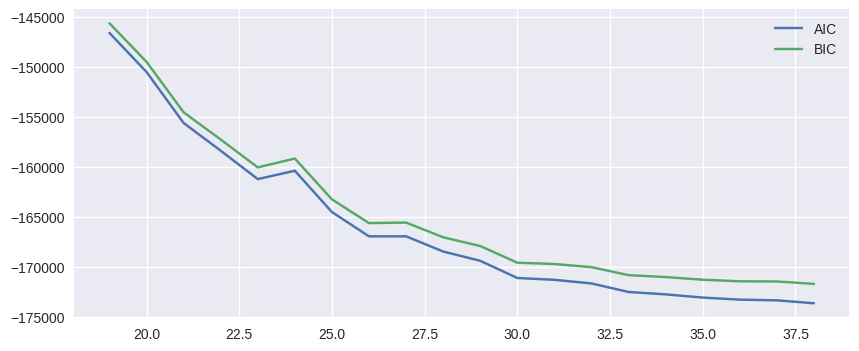

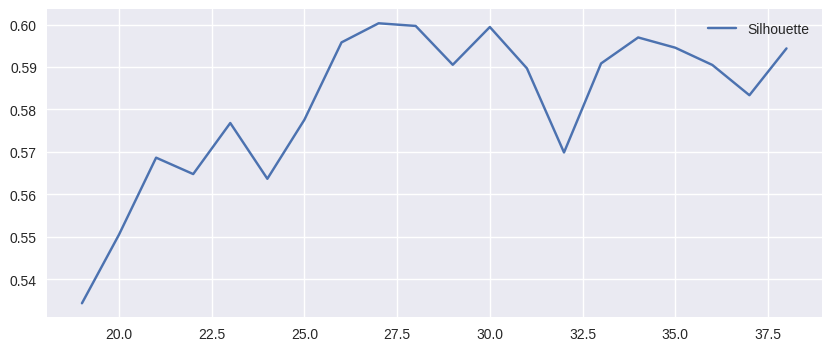

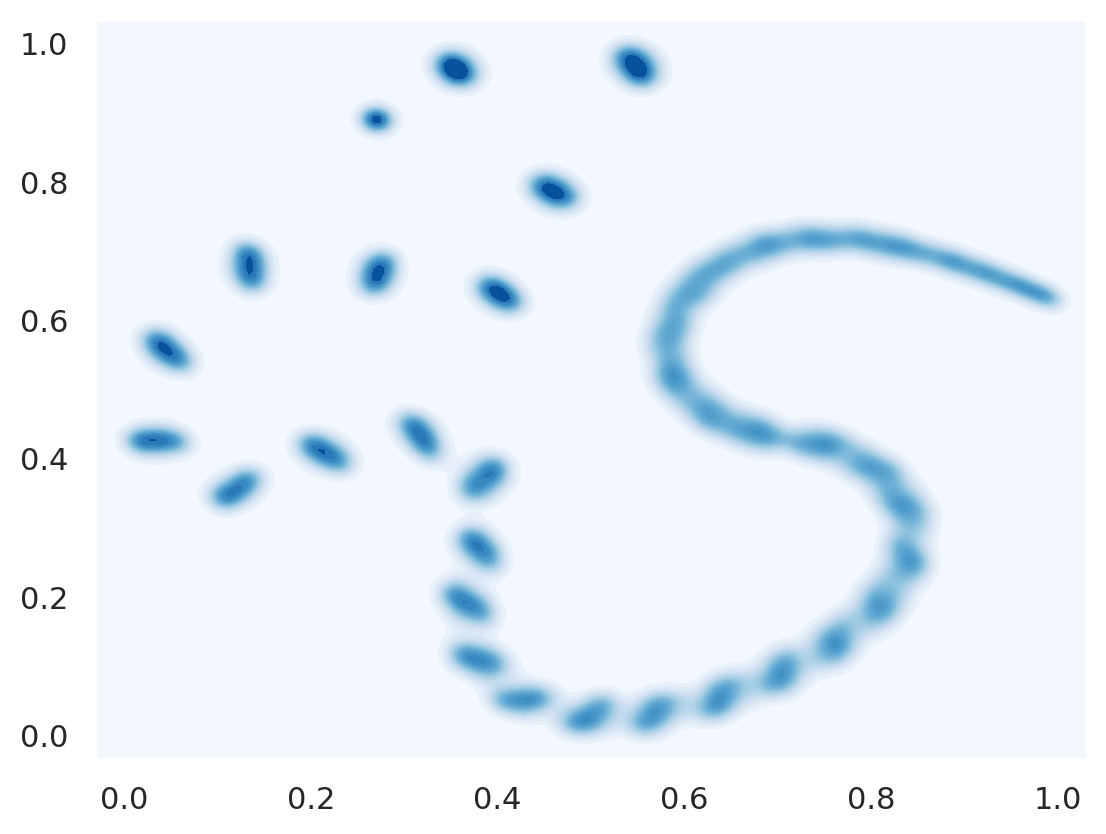

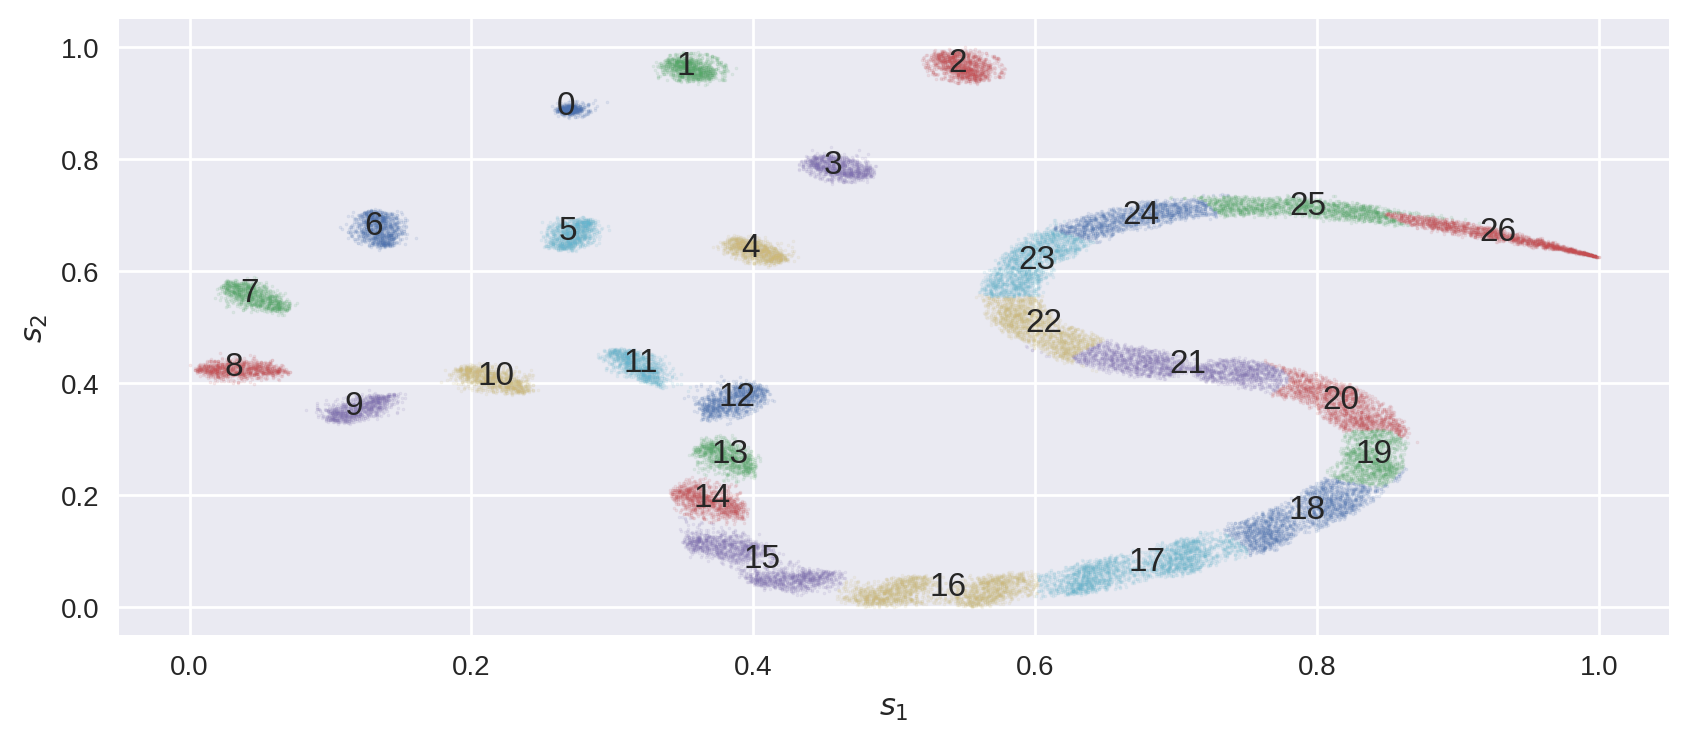

MemoryError: Unable to allocate 186. GiB for an array with shape (125019544, 200) and data type float64

In [6]:
kd = gaussian_mixture_2d(X_l_TSNE, data_test,
                    number_cluster=29,
                    cluster_iter = 10,
                    plot_sweep = True)

kd.plot_density(bw_adjust=0.25)
kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()
#kd.plot_traces(data_test)
#traces = kd.plot_traces_average(data_test)
#kd.plot_FWHM_average(data_test)
conf_tsne = kd.confidence

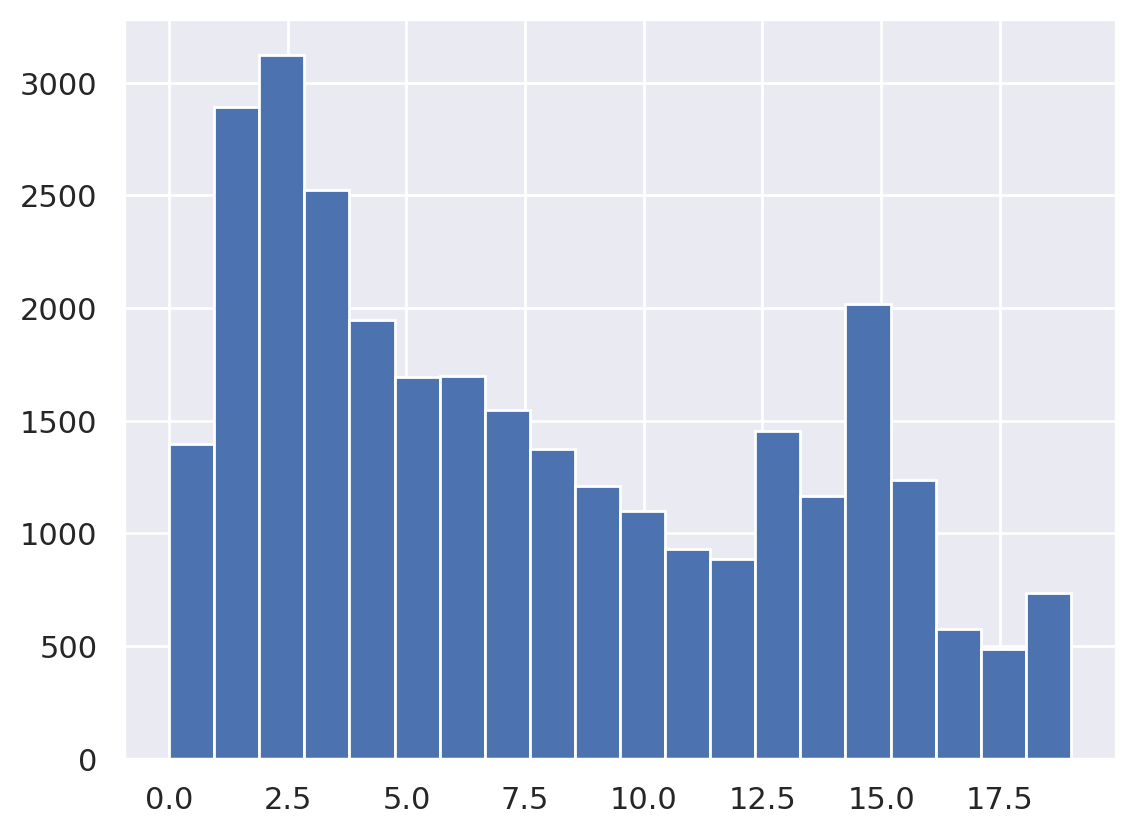

In [21]:
plt.hist(kd.labels,bins=len(np.unique(kd.labels)))
plt.show()

In [ ]:
n_cluster = 38
km = KMeans(n_cluster, init=traces, n_init='auto').fit(data_train)
labels_init = km.predict(data_test)

#plt.figure()
#plt.hist(labels_true,bins=n_cluster)
#plt.show()


labels_init = km.score(data_test)
labels_init

In [ ]:
from sklearn.cluster import KMeans
from scipy.integrate import simps

n_cluster = 38
kmeans = KMeans(n_clusters = n_cluster, random_state = 0, n_init='auto', init= traces)
kmeans.fit(data_test)
kmeans_labels_ = kmeans.predict(data_train) 

X_Area = simps(data_test).reshape(-1,1)

means_area = []
labels = []

for label in range(n_cluster):
    labels.append(label)
    means_area.append(np.mean(X_Area[kmeans.labels_ == label]))

means_area , labels = zip(*sorted(zip(means_area, labels)))
means_ = kmeans.cluster_centers_[list(labels)]

k = np.array(labels)
v = np.arange(len(means_))

labels_true = np.zeros_like(kmeans_labels_).flatten()
for key,val in zip(k,v):
    labels_true[kmeans_labels_==key] = val


labels_true = labels_true.astype('int')
plt.figure()
plt.hist(labels_true,bins=n_cluster)
plt.show()

plt.figure()
[plt.plot(i, c='b',alpha=0.5) for i in means_]
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
euc_res=euclidean_distances(traces, data_train)

# normalize the result  
#normlaized_res= (1/euc_res)/((1/euc_res).sum())
#convert to list and sort it 
#normlaized_res_list=normlaized_res.tolist()
#sorted_res=sorted(normlaized_res,reverse=True)
#get the nearset cluster 
#nearest_cluster=[]
#for i in sorted_res[:10] :
#    nearest_cluster.append(normlaized_res_list.index(i))
dist = np.array([euc_res[np.argmin(euc_res[:,i]), i] for i in range(len(labels_true))])
dist_cluster = []
for i in range(n_cluster):
    dist_cluster.append(dist[labels_true == i])

for index, value in enumerate(dist_cluster):
    plt.scatter(index, np.mean(value))
plt.show()

In [ ]:
t = 10
arr = np.arange(len(kmeans.cluster_centers_[0]))
plt.figure(figsize=(10,4))
[plt.plot((i*0.03+1)*arr, kmeans.cluster_centers_[-(t+1)], c='k', alpha=0.5) for i in range(30)]
#plt.plot(1.03*arr, , c='b',alpha=0.5)
plt.plot(arr, kmeans.cluster_centers_[-t], c='b',alpha=0.5)
plt.show()

In [ ]:
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()
kd.plot_traces(data_test)
kd.plot_traces_average(data_test)

### Spectral Embedding 

In [ ]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [11]:
X_i_NMF, X_l_NMF = dimension_reduction(data_train,data_test, path_save,NMF,n_components=2,alpha_W=1e-2,random_state=42)#0.75+np.copy(X_train),0.75+np.copy(X_test)
trust_NMF_eucl = trustworthiness(data_test, X_l_NMF, metric="euclidean")
trust_NMF_cos = trustworthiness(data_test, X_l_NMF, metric="cosine")

In [ ]:
kd = gaussian_mixture_2d(X_l_NMF, data_test,
                    number_cluster=37,#17,
                    cluster_iter = 10)    

kd.plot_density(bw_adjust=0.1)
kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()

### Isomap

In [12]:
X_i_ISO, X_l_ISO = dimension_reduction(data_train,data_test, path_save, Isomap, n_neighbors=100, n_components=2, eigen_solver="arpack")
trust_ISO_eucl = trustworthiness(data_test, X_l_ISO, metric="euclidean")
trust_ISO_cos = trustworthiness(data_test, X_l_ISO, metric="cosine")

In [ ]:
kd = gaussian_mixture_2d(X_l_ISO, data_test,
                    number_cluster=29,#17,
                    cluster_iter = 10)    

kd.plot_density(bw_adjust=0.25)
kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()
#kd.plot_traces(data_test)
#kd.plot_traces_average(data_test)

In [ ]:
kd = gaussian_mixture(X_l_ISO, 
                    number_cluster=24,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### Autoencoder



In [15]:
path_model = 'grid-search-TES 2D 4/run 17/fold 0'
X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', filter=False, flip=True)

In [ ]:
plot_traces(X_r_AUTO)

In [ ]:
from scipy.signal import peak_widths

width =[]
for index, trace in enumerate(X_r_AUTO):
    half = peak_widths((trace-np.max(trace)/2).flatten(), peaks=[np.argmax(trace)], rel_height=0.5)
    width.append(half[0])

width = np.array(width)

In [ ]:
plt.figure()
plt.hist(width.flatten(), bins=5000)
plt.show()

In [ ]:
kd = gaussian_mixture_2d(X_l_AUTO, data_test,
                    number_cluster=29)    

kd.plot_density(bw_adjust=0.15)
kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()
kd.plot_traces(data_test)
kd.plot_traces_average(data_test)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(kd.cluster_means[:15])
plt.show()

In [ ]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', 
                                                  filter=True, 
                                                  threshold=0.003)

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.scatter(X_l_AUTOF[:,0],X_l_AUTOF[:,1], s=1, alpha=0.01)#, c=X_l_AREA)
plt.show()

In [ ]:
kd = gaussian_mixture(X_l_AUTO, 
                    number_cluster=18,
                    flip = True)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

In [ ]:
plt.plot(kd.cluster_means[:14])
plt.show()

# Compare

In [ ]:
i = [X_i_MAX, X_i_AREA, X_i_PCA, #X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_S, 
     X_i_KPCA_C, X_i_NMF, 
     X_i_TSNE, X_i_ISO, 
      X_i_AUTO, X_i_AUTOF]
l = [X_l_MAX, X_l_AREA, X_l_PCA, #X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_S, 
     X_l_KPCA_C, X_l_NMF,
     X_l_TSNE, X_l_ISO,
      X_l_AUTO, X_l_AUTOF]
#r = [X_r_MAX, X_r_AREA, X_r_PCA, #X_r_KPCA_P, 
#     #X_r_KPCA_RBF, X_r_KPCA_S, 
#     X_r_KPCA_C, X_r_NMF,
#     X_r_TSNE, X_r_ISO, 
#      X_r_AUTO, X_r_AUTOF]
methods = ['Max', 'Area', 'PCA', #'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Sigmoid)', 
           'K-PCA (Cosine)', 'NMF', 
           't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
flip = [False, False,False,#False,False,False,
        False,False,False,False, True, False]
density_kernel = ['gaussian', 'gaussian', #'gaussian', #'gaussian', #'gaussian',
                  'gaussian', 'gaussian', 'gaussian', 'exponential', 'gaussian',
                  'gaussian', 'gaussian']
bw = [0.0032, 0.003, 0.0025, 0.0035,
      #0.005, 0.008, 0.0045, 
      0.0035, 0.015, 0.0045,
      0.003, 0.003]

#comp = compare(flip, density_kernel, bw)
#scores = comp.quality_metric_plot(i,l,methods, 23)

In [ ]:
#import numpy as np

#np.save("MetricLog/Metric_TES_25.5dB/MetricTES_23photons", scores)

In [14]:
trust_eucl = [trust_MAX_eucl, trust_AREA_eucl, trust_PCA_eucl, trust_KPCA_RBF_eucl, trust_KPCA_S_eucl, trust_KPCA_C_eucl, trust_tsne_eucl, trust_NMF_eucl, trust_ISO_eucl]
trust_cos = [trust_MAX_cos, trust_AREA_cos, trust_PCA_cos, trust_KPCA_RBF_cos, trust_KPCA_S_cos, trust_KPCA_C_cos, trust_tsne_cos, trust_NMF_cos, trust_ISO_cos]

In [17]:
Title = ['Max', 'Area', 'PCA', #'K-PCA (Polynomial)',
           'K-PCA (RBF)', 'K-PCA (Sigmoid)',
           'K-PCA (Cosine)', 'NMF', 't-SNE', 'Isomap',
           'Autoencoder']
metric_list = ['Silhouette','Calinski Harabasz','Davies Bouldin','trustworthiness Euclidian','trustworthiness Cosine']

#colors = get_color_gradient(r"#19889B", r"#F9F871", 10)
GREY98 = "#fafafa"
colors = ["#81C14B", "#81C14B", "#6D7680", "#6D7680", #"#6D7680", "#6D7680" , 
          "#6D7680", "#6D7680", "#E0607E", "#E0607E", "#79AEA3", "#79AEA3"]
ylim = [None, None, None, (0.9,1), (0.9,1)]

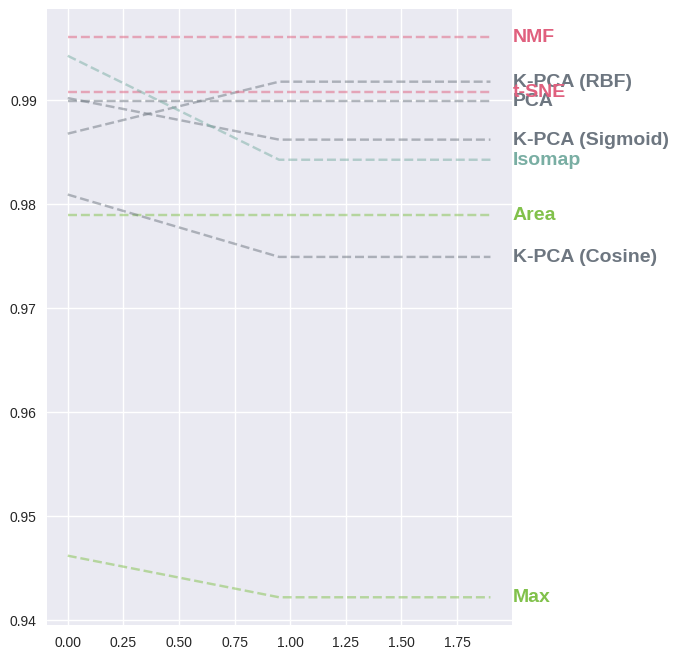

In [27]:
LABEL_Y = [# Positions Silhouette
    -0.004,  # Max
    0,  # Area
    -0.00,    # PCA
    #-0.013,   # K-PCA (Polynomial)
    0.005,  # K-PCA (RBF)
    -0.004,   # K-PCA (Sigmoid)
    -0.006,  # K-PCA (Cosine)
    0.0,    # NMF
    -0.00,  # t-SNE
    -0.01,  # Isomap
    0,  # Autoencoder
]

PAD = 0.1

with plt.style.context("seaborn-v0_8"):
    fig, axis = plt.subplots(figsize=(6,8))

    for index_method, score in enumerate(trust_eucl):

        sc = score
        sc = sc[sc != 0]
        color = colors[index_method]
        y_start = sc[-1]
        y_end = sc[-1] +LABEL_Y[index_method]
        x_start = len(sc)-1
        x_end = len(sc)+1

        axis.plot(score, c=color)
        axis.plot([x_start, (x_start + x_end - PAD) / 2 , x_end - PAD], 
                    [y_start, y_end, y_end], 
                    color=color, 
                    alpha=0.5, 
                    ls="dashed")
        axis.text(x_end, 
                y_end, 
                Title[index_method], 
                color=color, 
                fontsize=14, 
                weight="bold", 
                va="center")

    plt.show()

In [ ]:
for index_metric, metric_score in enumerate(scores):

    fig, axis = plt.subplots(figsize=(6,8))
    #fig.patch.set_facecolor(GREY98)
    #axis.set_facecolor(GREY98)

    for index_method, method in enumerate(Title):

        try:
            sc = scores[index_metric][index_method]
            sc = sc[sc != 0]
            color = colors[index_method]
            y_start = sc[-1]
            y_end = sc[-1] +LABEL_Y[index_metric][index_method]
            x_start = len(sc)-1
            x_end = len(sc)+1

            axis.plot(sc, label=f"{Title[index_method]}", c=color)
            axis.plot([x_start, (x_start + x_end - PAD) / 2 , x_end - PAD], 
                    [y_start, y_end, y_end], 
                    color=color, 
                    alpha=0.5, 
                    ls="dashed")
            axis.text(x_end, 
                    y_end, 
                    Title[index_method], 
                    color=color, 
                    fontsize=14, 
                    weight="bold", 
                    va="center")
        except:
            pass

    axis.set_xlim(0,31)
    axis.set_ylabel(f"{metric_list[index_metric]}")
    axis.set_xlabel('Photon number')
    if ylim[index_metric] != None:
        axis.set_ylim(ylim[index_metric][0],ylim[index_metric][1])
    #axis.set_yscale('log')
    plt.tight_layout()
    plt.show()